<a href="https://colab.research.google.com/github/KurniaYufi/sentiment-analysis-kematian-ali-khamenei/blob/main/tf-idf/article-tfidf-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TF-IDF Analysis Berita Kematian Ali Khamenei**

Notebook ini adalah **lanjutan langsung dari `3-Detik-POSTagging.ipynb`**. Input yang dibutuhkan adalah file `tagged_articles.csv`.

### Apa yang dianalisis:
| # | Analisis | Deskripsi |
|---|---|---|
| 1 | **Setup & Deteksi Kolom** | Impor library, load data, deteksi kolom otomatis |
| 2 | **Preprocessing** | Ekstraksi token dari POS tag |
| 3 | **TF-IDF Global** | Seluruh korpus, unigram + bigram + trigram |
| 4 | **N-Gram Analysis** | Breakdown uni/bi/trigram + visualisasi perbandingan |
| 5 | **TF-IDF per POS Tag** | NOUN, PROPN, VERB, ADJ, ADV |
| 6 | **TF-IDF per Kolom News** | Berdasarkan sumber/platform berita (kolom `News`) |
| 7 | **TF-IDF per Sentimen** | Positif, negatif, netral |
| 8 | **NER Analysis** | Named Entity Recognition dari pos_tags |
| 9 | **Kata Kunci per Dokumen** | Top-5 keyword per artikel |
| 10 | **Visualisasi Lengkap** | 15+ chart & word cloud |
| 11 | **Ringkasan & Ekspor** | Insight otomatis + CSV output |


# **(1) Installation & Setup**

In [3]:
!pip install wordcloud matplotlib seaborn scikit-learn pandas numpy tqdm -q
print('✅ Instalasi selesai.')

✅ Instalasi selesai.


In [4]:
import pandas as pd
import numpy as np
import ast, re, io, os, warnings
from collections import Counter, defaultdict
from itertools import chain

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# ─── Konstanta global ────────────────────────────────────────────────────────
RELEVANT_POS   = {'NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV'}
SEMANTIC_POS   = {'NOUN', 'PROPN', 'VERB', 'ADJ'}   # untuk teks utama TF-IDF
POS_CONFIG = {
    'NOUN' : ('Kata Benda',  '#4C72B0'),
    'PROPN': ('Nama Diri',   '#DD8452'),
    'VERB' : ('Kata Kerja',  '#55A868'),
    'ADJ'  : ('Kata Sifat',  '#C44E52'),
    'ADV'  : ('Keterangan',  '#8172B2'),
}
TOP_N = 15   # jumlah term yang ditampilkan di chart

print('✅ Library berhasil diimpor.')

✅ Library berhasil diimpor.


# **(2) Load Data & Deteksi Kolom Otomatis**

In [6]:
from google.colab import files
uploaded = files.upload()

df = pd.DataFrame()
for fn, content in uploaded.items():
    try:
        df = pd.read_csv(io.BytesIO(content))
        print(f'✅ Dimuat: "{fn}" → {df.shape[0]:,} baris × {df.shape[1]} kolom')
    except Exception as e:
        print(f'❌ Error: {e}')

print('\nKolom yang tersedia:')
for c in df.columns:
    print(f'  • {c} ({df[c].dtype})  — {df[c].notna().sum()} non-null')

Saving tagged_articles.csv to tagged_articles.csv
✅ Dimuat: "tagged_articles.csv" → 491 baris × 15 kolom

Kolom yang tersedia:
  • News (object)  — 491 non-null
  • url (object)  — 491 non-null
  • title (object)  — 491 non-null
  • content (object)  — 491 non-null
  • text_cleaned (object)  — 491 non-null
  • tokens (object)  — 491 non-null
  • tokens_no_stop (object)  — 491 non-null
  • tokens_stemmed (object)  — 491 non-null
  • text_final (object)  — 491 non-null
  • polarity (float64)  — 491 non-null
  • subjectivity (float64)  — 490 non-null
  • sentiment_label (object)  — 491 non-null
  • pos_tags (object)  — 491 non-null
  • lemma_tags (object)  — 491 non-null
  • ner_tags (object)  — 491 non-null


In [7]:
def detect_col(df, candidates, default=None):
    """Cari kolom pertama yang namanya cocok dari daftar kandidat (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return default

COL_TEXT      = detect_col(df, ['text_final', 'text_clean', 'content_cleaned', 'text', 'content'], df.columns[0])
COL_POSTAGS   = detect_col(df, ['pos_tags', 'pos_tag', 'postags'])
COL_TITLE     = detect_col(df, ['title', 'judul', 'headline'])
COL_DATE      = detect_col(df, ['date', 'tanggal', 'published_at', 'publish_date', 'created_at'])
COL_CHANNEL   = detect_col(df, ['News', 'news', 'channel', 'kanal', 'section', 'category', 'rubrik', 'topic'])
COL_DOCTYPE   = detect_col(df, ['type', 'doc_type', 'document_type', 'jenis', 'label'])
COL_SENTIMENT = detect_col(df, ['sentiment', 'sentimen', 'sentiment_label', 'label_sentimen'])

print('=== Hasil Deteksi Kolom ===')
print(f'  Teks utama    : {COL_TEXT}')
print(f'  POS tags      : {COL_POSTAGS}')
print(f'  Judul         : {COL_TITLE}')
print(f'  Tanggal       : {COL_DATE}')
print(f'  Kanal/Kategori: {COL_CHANNEL}')
print(f'  Tipe dokumen  : {COL_DOCTYPE}')
print(f'  Sentimen      : {COL_SENTIMENT}')
print()
print('   Kolom bertanda None tidak ditemukan → analisis segmen terkait akan dilewati.')
print('   Ubah nilai variabel COL_* di atas jika nama kolom di dataset Anda berbeda.')

=== Hasil Deteksi Kolom ===
  Teks utama    : text_final
  POS tags      : pos_tags
  Judul         : title
  Tanggal       : None
  Kanal/Kategori: News
  Tipe dokumen  : None
  Sentimen      : sentiment_label

   Kolom bertanda None tidak ditemukan → analisis segmen terkait akan dilewati.
   Ubah nilai variabel COL_* di atas jika nama kolom di dataset Anda berbeda.


# **(3) Preprocessing: Ekstraksi Token dari POS Tags**

In [8]:
def parse_pos_tags(val):
    if isinstance(val, list): return val
    if isinstance(val, str):
        try:    return ast.literal_eval(val)
        except: return []
    return []

if COL_POSTAGS:
    df[COL_POSTAGS] = df[COL_POSTAGS].apply(parse_pos_tags)
    print(f'   Kolom "{COL_POSTAGS}" berhasil di-parse.')
    print(f'   Contoh (baris 0): {df[COL_POSTAGS].iloc[0][:8]}')
else:
    print('   Kolom pos_tags tidak ditemukan. Preprocessing dari pos_tags dilewati.')
    print('   TF-IDF akan dijalankan langsung dari kolom teks.')

def clean_token(word):
    """Bersihkan token: lowercase, hanya huruf, minimal 3 karakter."""
    t = re.sub(r'[^a-zA-Z]', '', word.lower())
    return t if len(t) >= 3 else None

def extract_by_pos(pos_list, tags=None):
    """Ekstrak token berdasarkan set POS tag."""
    target = tags if tags else SEMANTIC_POS
    out = []
    for word, tag in pos_list:
        if tag in target:
            t = clean_token(word)
            if t: out.append(t)
    return out

def extract_all_tokens(pos_list):
    """Semua token apapun POS-nya (untuk NER)."""
    return [(word, tag) for word, tag in pos_list]

if COL_POSTAGS:
    df['text_semantic'] = df[COL_POSTAGS].apply(
        lambda x: ' '.join(extract_by_pos(x)))
    for tag in POS_CONFIG:
        df[f'text_{tag}'] = df[COL_POSTAGS].apply(
            lambda x: ' '.join(extract_by_pos(x, {tag})))
else:
    df['text_semantic'] = df[COL_TEXT].fillna('').astype(str)

if COL_DATE:
    df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce')
    df['bulan']    = df[COL_DATE].dt.to_period('M').astype(str)
    df['kuartal']  = df[COL_DATE].dt.to_period('Q').astype(str)
    print(f'✅ Kolom tanggal "{COL_DATE}" diproses.')
    print(f'   Rentang: {df[COL_DATE].min()} → {df[COL_DATE].max()}')

print('\n=== Statistik Token per POS ===')
for col_suffix in ['semantic'] + list(POS_CONFIG.keys()):
    col = f'text_{col_suffix}'
    if col in df.columns:
        avg = df[col].apply(lambda x: len(x.split())).mean()
        print(f'  {col:<18}: rata-rata {avg:.1f} token/dok')

   Kolom "pos_tags" berhasil di-parse.
   Contoh (baris 0): [('ketua', 'NOUN'), ('dpr', 'NOUN'), ('ri', 'PROPN'), ('puan', 'PROPN'), ('maharani', 'PROPN'), ('menyampaikan', 'VERB'), ('dukacita', 'NOUN'), ('ke', 'ADP')]

=== Statistik Token per POS ===
  text_semantic     : rata-rata 222.6 token/dok
  text_NOUN         : rata-rata 140.6 token/dok
  text_PROPN        : rata-rata 14.9 token/dok
  text_VERB         : rata-rata 46.8 token/dok
  text_ADJ          : rata-rata 20.2 token/dok
  text_ADV          : rata-rata 10.1 token/dok


# **(4) TF-IDF Global + N-Gram Analysis**

Bagian ini menghitung TF-IDF dari seluruh korpus dan memecah hasilnya berdasarkan tipe N-gram: **unigram** (1 kata), **bigram** (2 kata), dan **trigram** (3 kata).

In [9]:
corpus = df['text_semantic'].fillna('').astype(str)

# Vectorizer global (unigram + bigram + trigram)
vec_global = TfidfVectorizer(
    max_features=800,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    smooth_idf=True
)
mat_global  = vec_global.fit_transform(corpus)
feat_global = vec_global.get_feature_names_out()
df_tfidf    = pd.DataFrame(mat_global.toarray(), columns=feat_global)
importance_global = df_tfidf.mean(axis=0).sort_values(ascending=False)

# Calculate document frequency for the terms in feat_global
# Using CountVectorizer to get raw counts and then sum up document occurrences
count_vec_for_df = CountVectorizer(
    vocabulary=feat_global, # Use the same vocabulary as TF-IDF to ensure consistency
    ngram_range=(1, 3)      # Ensure the same ngram_range
)
count_mat_for_df = count_vec_for_df.fit_transform(corpus)
# Count documents where each term appears at least once
df_freq_arr = (count_mat_for_df > 0).sum(axis=0)
df_freq_arr = pd.Series(df_freq_arr.A1, index=feat_global)

# Pisahkan per N-gram
ngram_importance = {}
for n, label in [(1,'Unigram (1 kata)'), (2,'Bigram (2 kata)'), (3,'Trigram (3 kata)')]:
    mask = np.array([len(t.split())==n for t in feat_global])
    if mask.sum() == 0:
        print(f'⚠️  Tidak ada {label} ditemukan.')
        continue
    scores = importance_global[feat_global[mask]].sort_values(ascending=False)
    ngram_importance[n] = (label, scores)

print(f'✅ Matriks TF-IDF Global:')
print(f'   Dimensi  : {mat_global.shape[0]:,} dok × {mat_global.shape[1]:,} fitur')
sparsity = 1 - mat_global.nnz / (mat_global.shape[0]*mat_global.shape[1])
print(f'   Sparsity : {sparsity*100:.1f}%')
for n, (label, scores) in ngram_importance.items():
    print(f'   {label}: {len(scores)} term')

print(f'\n=== Top {TOP_N} Term Global ===')
display(importance_global.head(TOP_N).reset_index().rename(
    columns={'index':'term', 0:'avg_tfidf'}))

✅ Matriks TF-IDF Global:
   Dimensi  : 491 dok × 800 fitur
   Sparsity : 85.3%
   Unigram (1 kata): 560 term
   Bigram (2 kata): 167 term
   Trigram (3 kata): 73 term

=== Top 15 Term Global ===


,term,avg_tfidf
0,serangan,0.057065
1,israel,0.055428
2,pemimpin tertinggi,0.043782
3,trump,0.040286
4,amerika,0.039856
5,ayatol,0.039021
6,tewas,0.038252
7,militer,0.037150
8,tertinggi iran,0.036719
9,teheran,0.036443


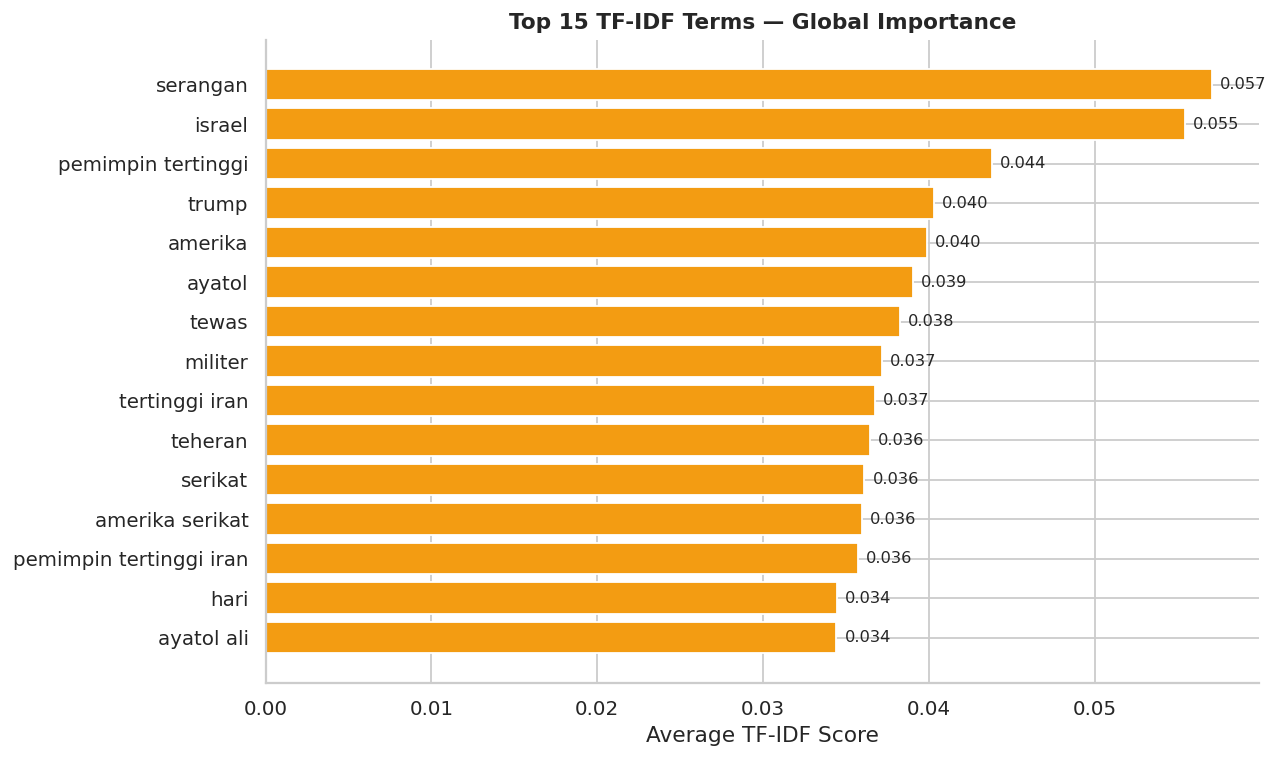

💾 viz_tfidf_bar.png


In [10]:
ORANGE = '#F39C12'

if 'importance_global' in dir() and not importance_global.empty:
    plt.figure(figsize=(10, 6))

    top_terms = importance_global.head(TOP_N)

    bars = plt.barh(top_terms.index[::-1], top_terms.values[::-1],
                    color=ORANGE, edgecolor='white')

    # Label angka
    for bar, val in zip(bars, top_terms.values[::-1]):
        plt.text(bar.get_width() + 0.0005,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

    plt.title(f'Top {TOP_N} TF-IDF Terms — Global Importance',
              fontsize=12, fontweight='bold')
    plt.xlabel('Average TF-IDF Score')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('viz_tfidf_bar.png', bbox_inches='tight', dpi=150)
    plt.show()

    print('💾 viz_tfidf_bar.png')

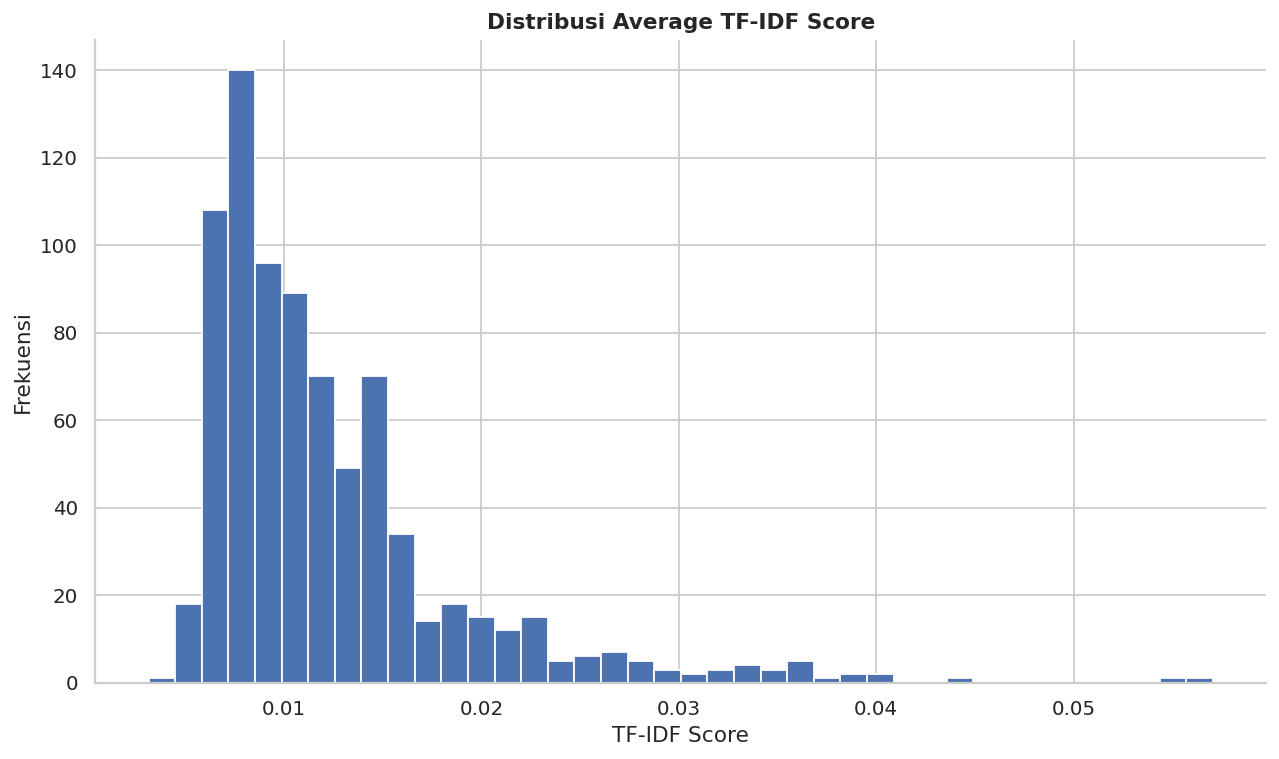

💾 viz_tfidf_distribution.png


In [11]:
if 'importance_global' in dir() and not importance_global.empty:
    plt.figure(figsize=(10, 6))

    values = importance_global.values

    plt.hist(values, bins=40, color='#4C72B0')

    plt.title('Distribusi Average TF-IDF Score',
              fontsize=12, fontweight='bold')
    plt.xlabel('TF-IDF Score')
    plt.ylabel('Frekuensi')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('viz_tfidf_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()

    print('💾 viz_tfidf_distribution.png')

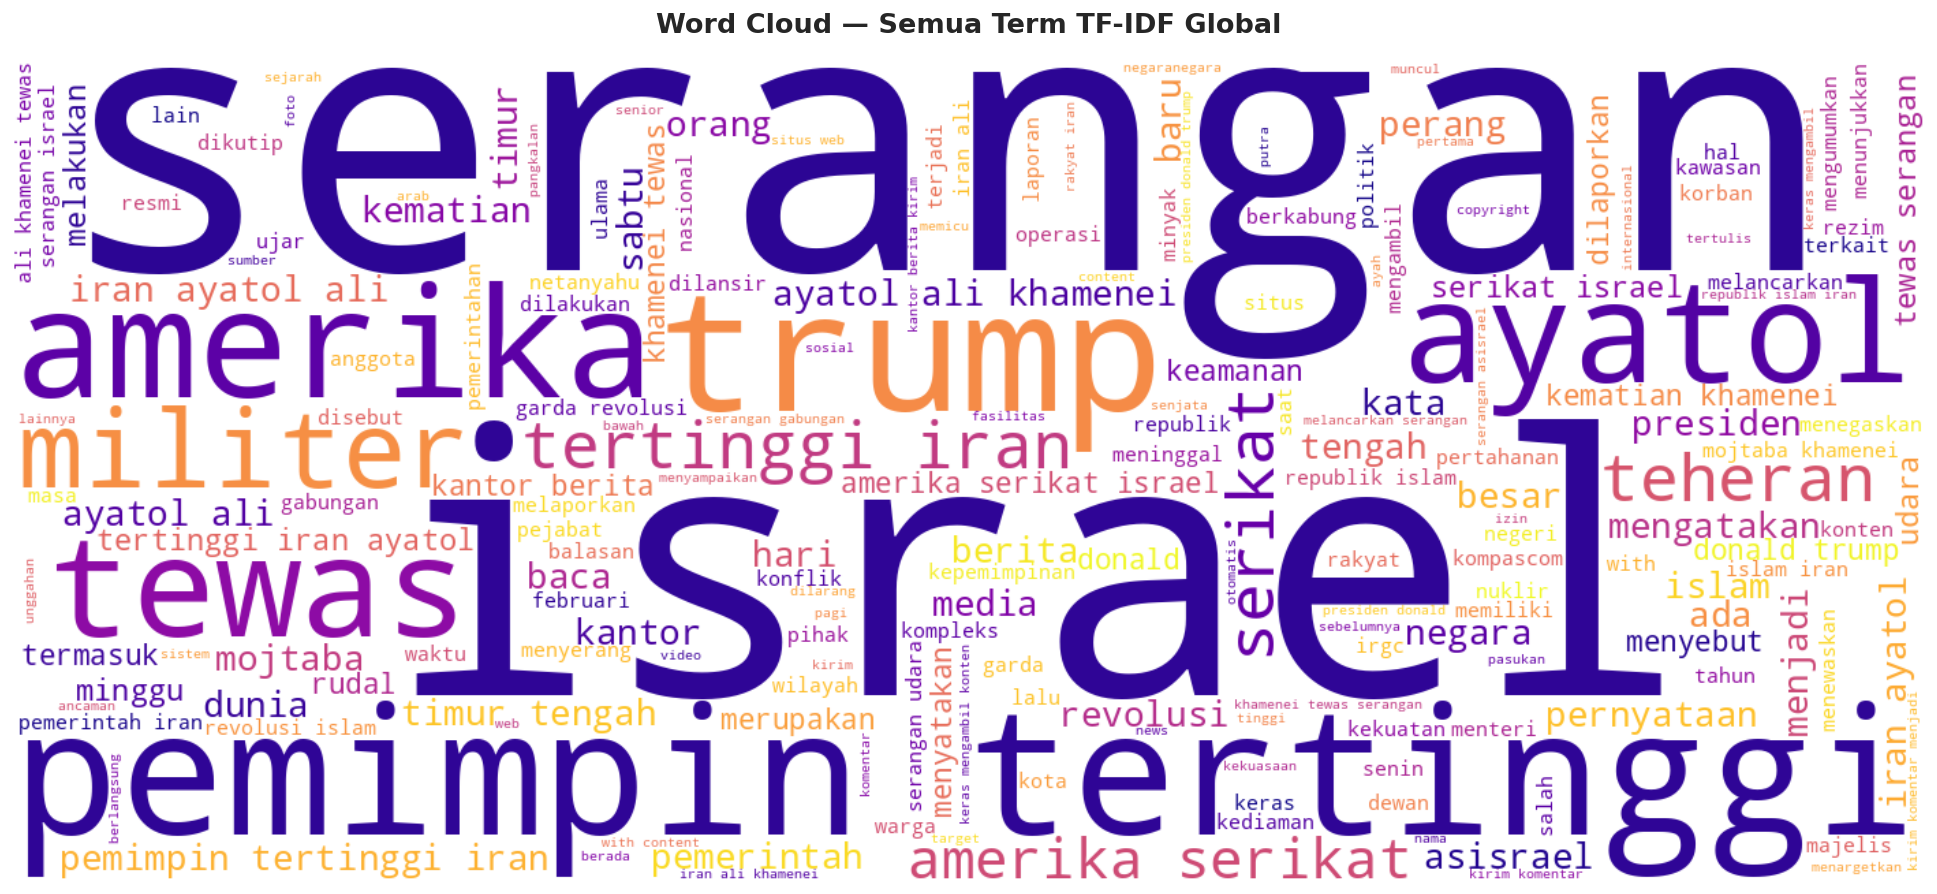

💾 viz_wordcloud_global.png


In [12]:
# Word Cloud Global
wc = WordCloud(width=1400, height=600, background_color='white',
               colormap='plasma', max_words=200, prefer_horizontal=0.8
               ).generate_from_frequencies(importance_global.to_dict())
fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title('Word Cloud — Semua Term TF-IDF Global',
             fontsize=15, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('viz_wordcloud_global.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 viz_wordcloud_global.png')

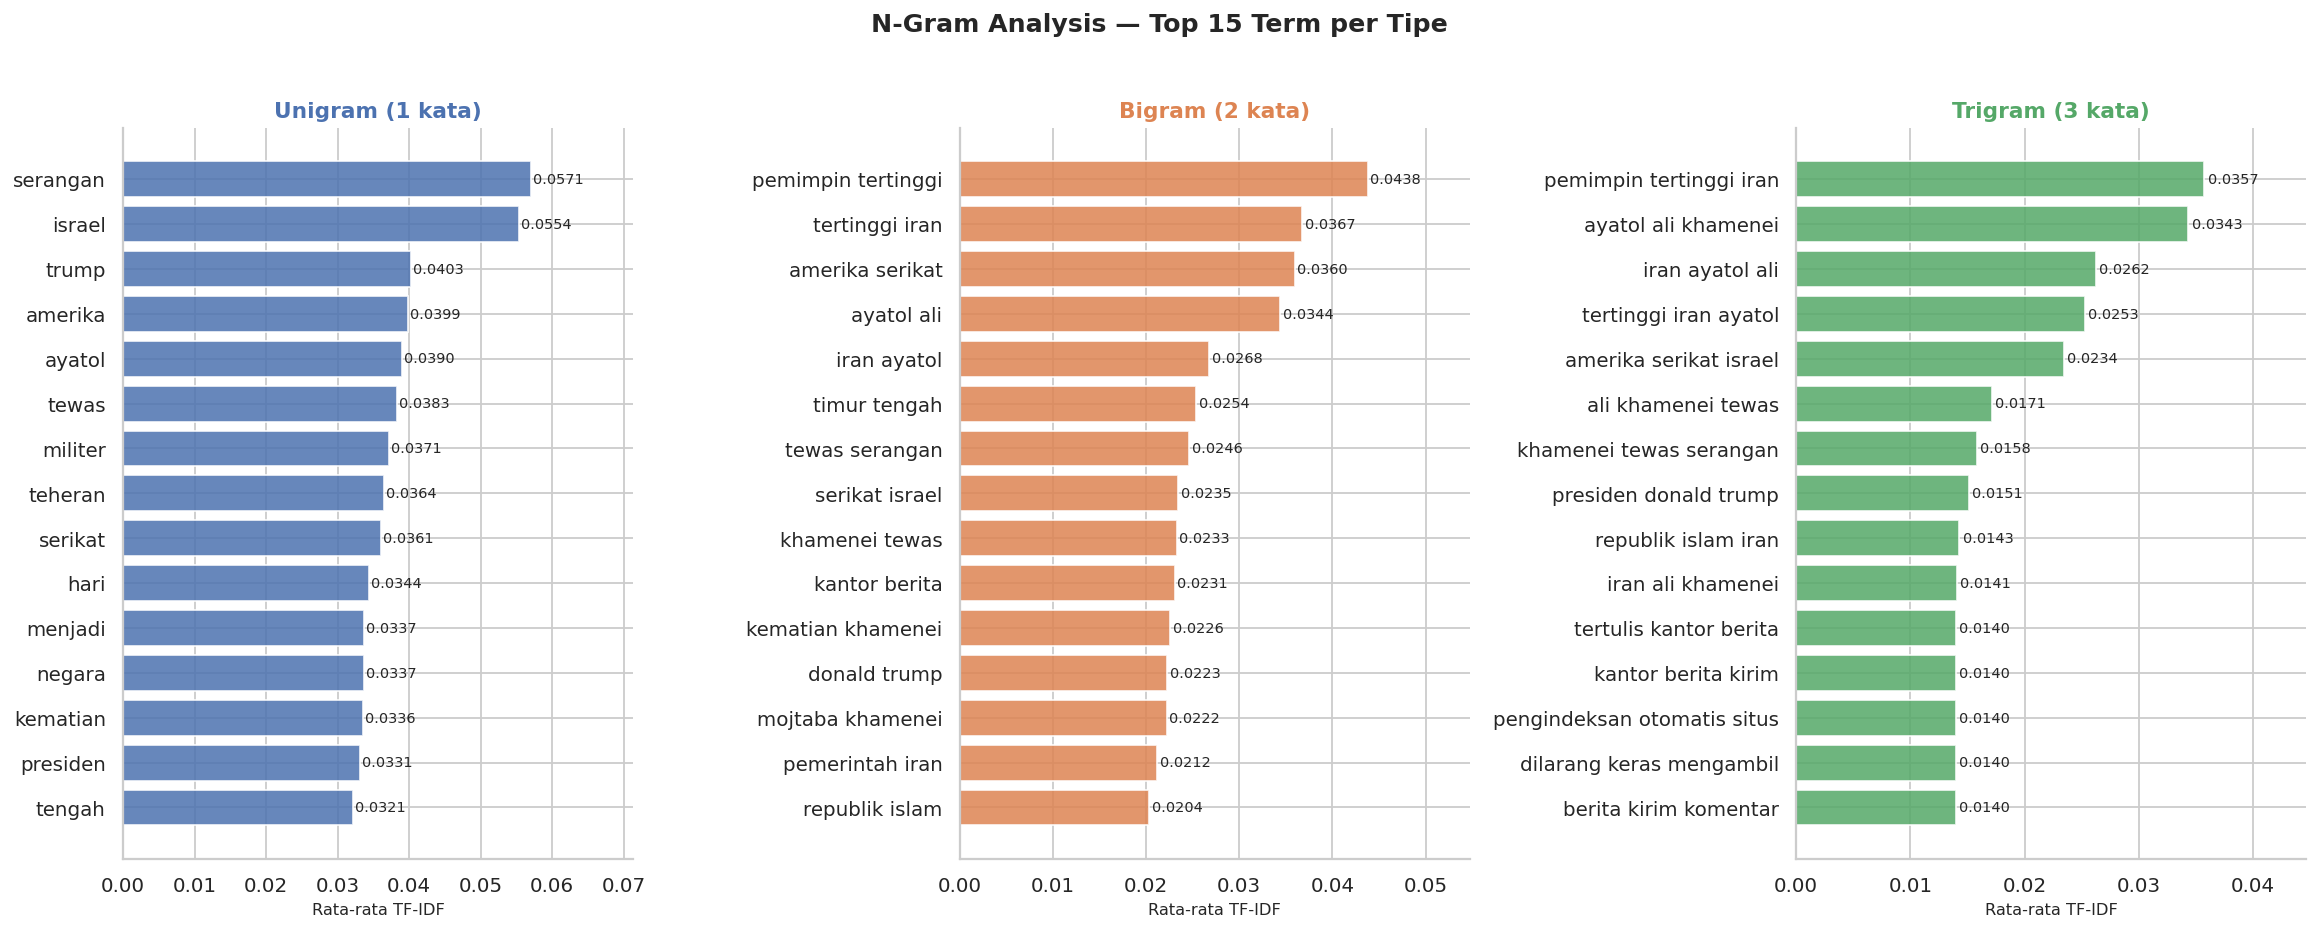

💾 viz_ngram_comparison.png


In [13]:
# Visualisasi N-gram Comparison
n_types = len(ngram_importance)
fig, axes = plt.subplots(1, n_types, figsize=(6*n_types, 7), sharey=False)
if n_types == 1: axes = [axes]

palettes = {1:'#4C72B0', 2:'#DD8452', 3:'#55A868'}
for ax, (n, (label, scores)) in zip(axes, ngram_importance.items()):
    top = scores.head(TOP_N)
    bars = ax.barh(top.index[::-1], top.values[::-1],
                   color=palettes.get(n,'gray'), alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, top.values[::-1]):
        ax.text(bar.get_width()+0.0003, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_title(label, fontsize=12, fontweight='bold', color=palettes.get(n,'gray'))
    ax.set_xlabel('Rata-rata TF-IDF', fontsize=9)
    ax.set_xlim(0, top.max()*1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'N-Gram Analysis — Top {TOP_N} Term per Tipe',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_ngram_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 viz_ngram_comparison.png')

# **(5) TF-IDF per POS Tag**

Menghitung TF-IDF secara terpisah untuk setiap kelas kata: **NOUN** (kata benda), **PROPN** (nama diri/entitas), **VERB** (kata kerja), **ADJ** (kata sifat), **ADV** (keterangan).

✅ Kata Benda (NOUN): 200 fitur
✅ Nama Diri (PROPN): 200 fitur
✅ Kata Kerja (VERB): 200 fitur
✅ Kata Sifat (ADJ): 200 fitur
✅ Keterangan (ADV): 115 fitur


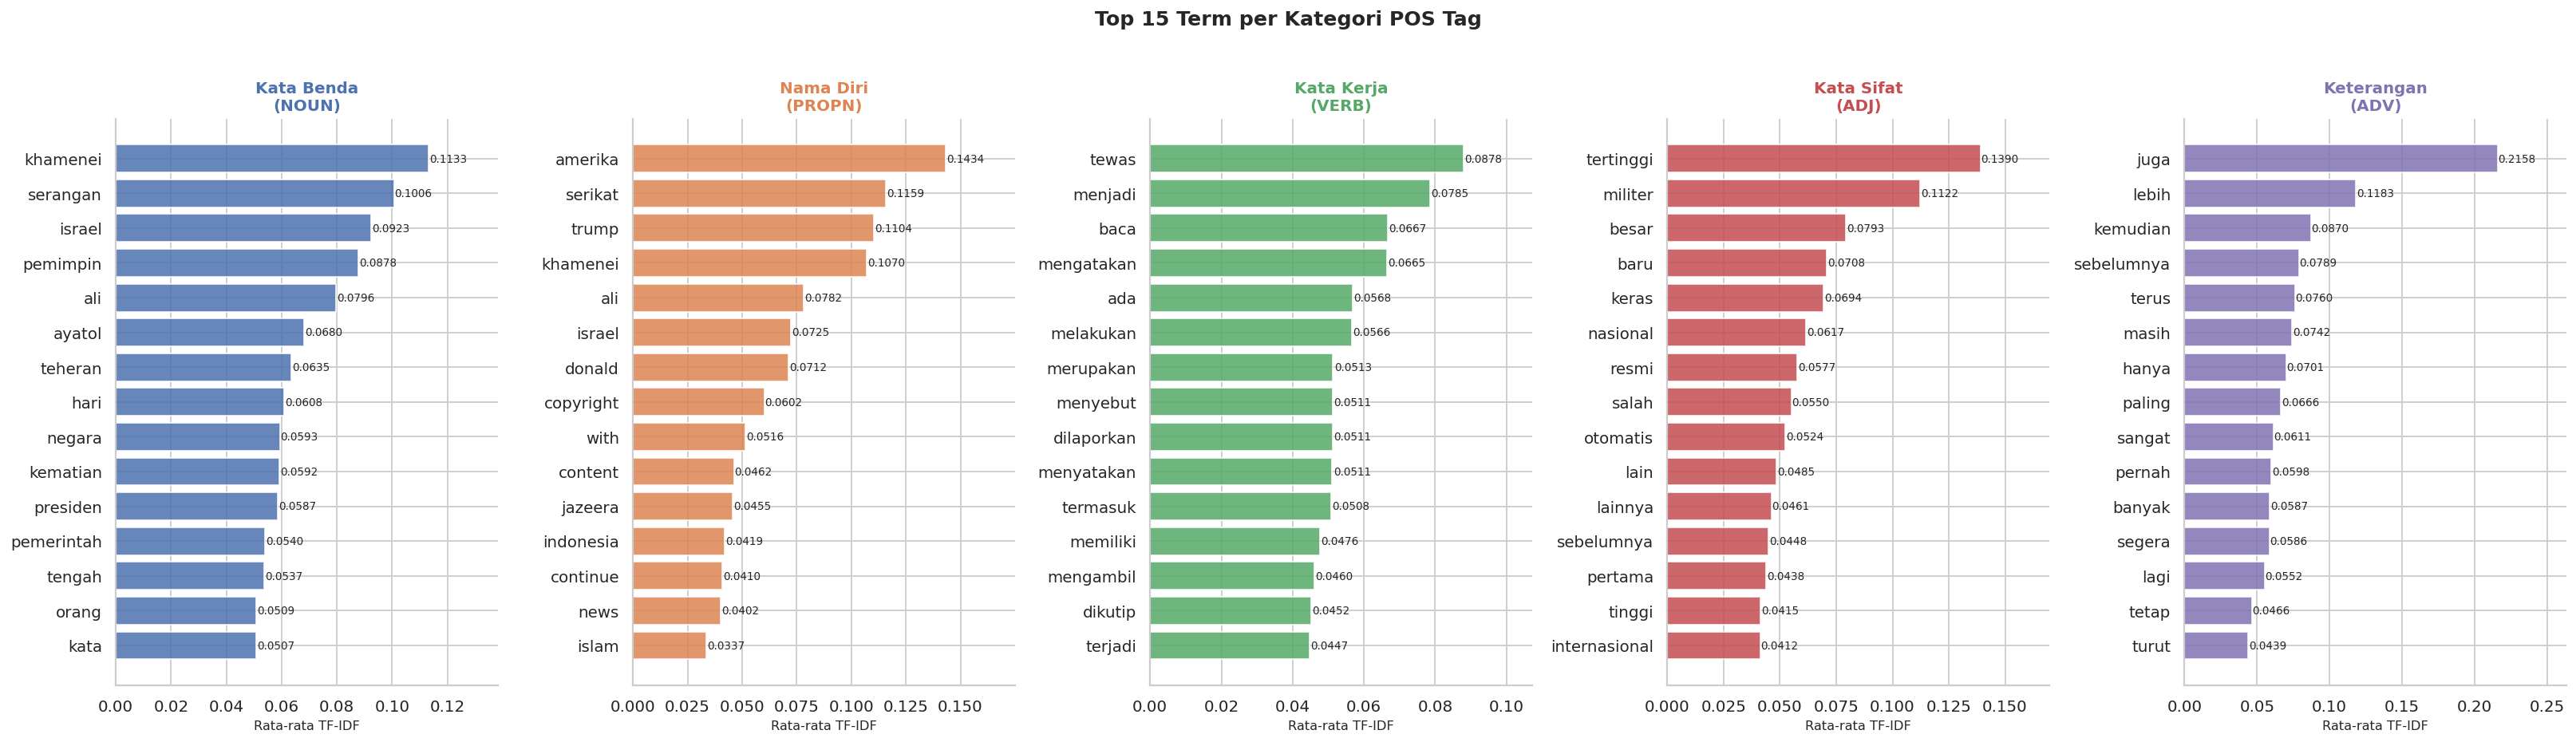

💾 viz_tfidf_per_pos.png


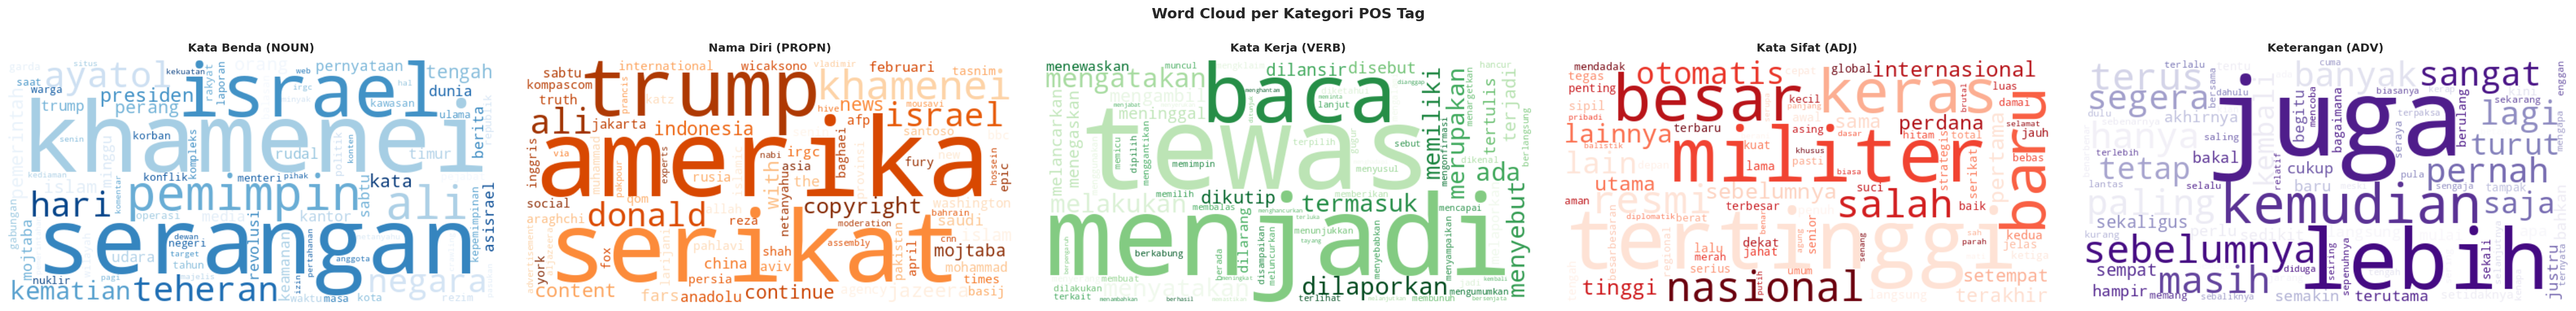

💾 viz_wordcloud_per_pos.png


In [14]:
tfidf_pos = {}   # tag → (vectorizer, matrix, importance_series)

if COL_POSTAGS:
    for tag, (label, color) in POS_CONFIG.items():
        col = f'text_{tag}'
        if col not in df.columns: continue
        corpus_pos = df[col].fillna('').astype(str)
        valid = corpus_pos[corpus_pos.str.strip() != '']
        if len(valid) < 5:
            print(f'⚠️  {label} ({tag}): data terlalu sedikit, dilewati.')
            continue
        vec = TfidfVectorizer(max_features=200, ngram_range=(1,1),
                              min_df=2, max_df=0.95, sublinear_tf=True)
        mat = vec.fit_transform(corpus_pos)
        imp = pd.DataFrame(mat.toarray(), columns=vec.get_feature_names_out()
                          ).mean(axis=0).sort_values(ascending=False)
        tfidf_pos[tag] = (vec, mat, imp)
        print(f'✅ {label} ({tag}): {mat.shape[1]} fitur')
else:
    print('⚠️  Kolom pos_tags tidak tersedia — bagian ini dilewati.')

# Visualisasi bar chart per POS
if tfidf_pos:
    n_pos = len(tfidf_pos)
    fig, axes = plt.subplots(1, n_pos, figsize=(5*n_pos, 7))
    if n_pos == 1: axes = [axes]

    for ax, (tag, (vec, mat, imp)) in zip(axes, tfidf_pos.items()):
        label, color = POS_CONFIG[tag]
        top = imp.head(TOP_N)
        bars = ax.barh(top.index[::-1], top.values[::-1],
                       color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, top.values[::-1]):
            ax.text(bar.get_width()+0.0003, bar.get_y()+bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=7.5)
        ax.set_title(f'{label}\n({tag})', fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Rata-rata TF-IDF', fontsize=9)
        ax.set_xlim(0, top.max()*1.22)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    fig.suptitle(f'Top {TOP_N} Term per Kategori POS Tag',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('viz_tfidf_per_pos.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('💾 viz_tfidf_per_pos.png')

    # Word Cloud per POS
    CMAPS = {'NOUN':'Blues','PROPN':'Oranges','VERB':'Greens','ADJ':'Reds','ADV':'Purples'}
    fig, axes = plt.subplots(1, n_pos, figsize=(7*n_pos, 4))
    if n_pos == 1: axes = [axes]
    for ax, (tag, (vec, mat, imp)) in zip(axes, tfidf_pos.items()):
        label, _ = POS_CONFIG[tag]
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=CMAPS.get(tag,'viridis'), max_words=80
                       ).generate_from_frequencies(imp.to_dict())
        ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
        ax.set_title(f'{label} ({tag})', fontsize=11, fontweight='bold', pad=8)
    fig.suptitle('Word Cloud per Kategori POS Tag', fontsize=14, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig('viz_wordcloud_per_pos.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('💾 viz_wordcloud_per_pos.png')

# **(6) TF-IDF per Kolom News (Sumber/Platform Berita)**

Menghitung TF-IDF secara terpisah untuk setiap **sumber atau platform berita** yang tercantum dalam kolom `News` (misalnya: Detik, Kompas, Tempo, CNN Indonesia, dll.).

**Tujuan analisis ini:**
- Membandingkan *vocabulary* yang khas di tiap platform berita
- Mengidentifikasi perbedaan framing pemberitaan antar media
- Mengetahui term apa yang hanya muncul dominan di satu sumber berita tertentu

> **Catatan:** Segmentasi berdasarkan sumber berita (`News`) relevan karena setiap media memiliki gaya redaksional, sudut pandang, dan pilihan kata yang berbeda — sehingga TF-IDF per `News` mengungkap *editorial fingerprint* masing-masing platform.


In [15]:
def tfidf_per_segment(df, segment_col, text_col, label_col_name='Segmen',
                      min_docs=3, max_features=300, top_n=TOP_N):
    """
    Hitung TF-IDF per segmen (sumber berita, sentimen, dll).
    Return: dict {segmen: importance_series}
    """
    results = {}
    groups = df.groupby(segment_col)[text_col].apply(list)
    for seg, docs in groups.items():
        docs_clean = [d for d in docs if isinstance(d, str) and d.strip()]
        if len(docs_clean) < min_docs:
            print(f'  ⚠️  {label_col_name} "{seg}": hanya {len(docs_clean)} dok, dilewati.')
            continue
        vec = TfidfVectorizer(max_features=max_features, ngram_range=(1,2),
                              min_df=2, max_df=0.95, sublinear_tf=True)
        try:
            mat = vec.fit_transform(docs_clean)
            imp = pd.DataFrame(mat.toarray(), columns=vec.get_feature_names_out()
                              ).mean(axis=0).sort_values(ascending=False)
            results[seg] = imp
        except ValueError as e:
            print(f'  ⚠️  {label_col_name} "{seg}": {e}')
    return results


def plot_segment_top_words(results, title, fname, top_n=TOP_N, ncols=3):
    """Buat subplot grid: 1 bar chart per segmen."""
    segs = list(results.keys())
    n = len(segs)
    if n == 0:
        print('Tidak ada data untuk divisualisasikan.'); return
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows), squeeze=False)
    palette = sns.color_palette('Set2', n)

    for idx, seg in enumerate(segs):
        ax = axes[idx//ncols][idx%ncols]
        top = results[seg].head(top_n)
        color = palette[idx]
        bars = ax.barh(top.index[::-1], top.values[::-1],
                       color=color, alpha=0.87, edgecolor='white')
        for bar, val in zip(bars, top.values[::-1]):
            ax.text(bar.get_width()+0.0003, bar.get_y()+bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=7.5)
        ax.set_title(str(seg), fontsize=11, fontweight='bold')
        ax.set_xlabel('Avg TF-IDF', fontsize=8)
        ax.set_xlim(0, top.max()*1.22)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Sembunyikan subplot kosong
    for idx in range(n, nrows*ncols):
        axes[idx//ncols][idx%ncols].set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'💾 {fname}')


# ─── Jalankan TF-IDF per Kolom News ─────────────────────────────────────────
if COL_CHANNEL and COL_CHANNEL in df.columns:
    print(f'=== Sumber Berita yang Ditemukan (kolom: "{COL_CHANNEL}") ===')
    print(df[COL_CHANNEL].value_counts().to_string())
    results_channel = tfidf_per_segment(
        df, COL_CHANNEL, 'text_semantic', label_col_name='News')
    print(f'\n✅ Berhasil: {len(results_channel)} sumber berita dianalisis')
else:
    print('⚠️  Kolom News tidak ditemukan atau kosong.')
    print('   Pastikan kolom "News" ada di dataset, atau sesuaikan COL_CHANNEL di bagian (2).')
    results_channel = {}


=== Sumber Berita yang Ditemukan (kolom: "News") ===
News
Tribun    100
Antara    100
CNN        99
Detik      96
Kompas     96

✅ Berhasil: 5 sumber berita dianalisis


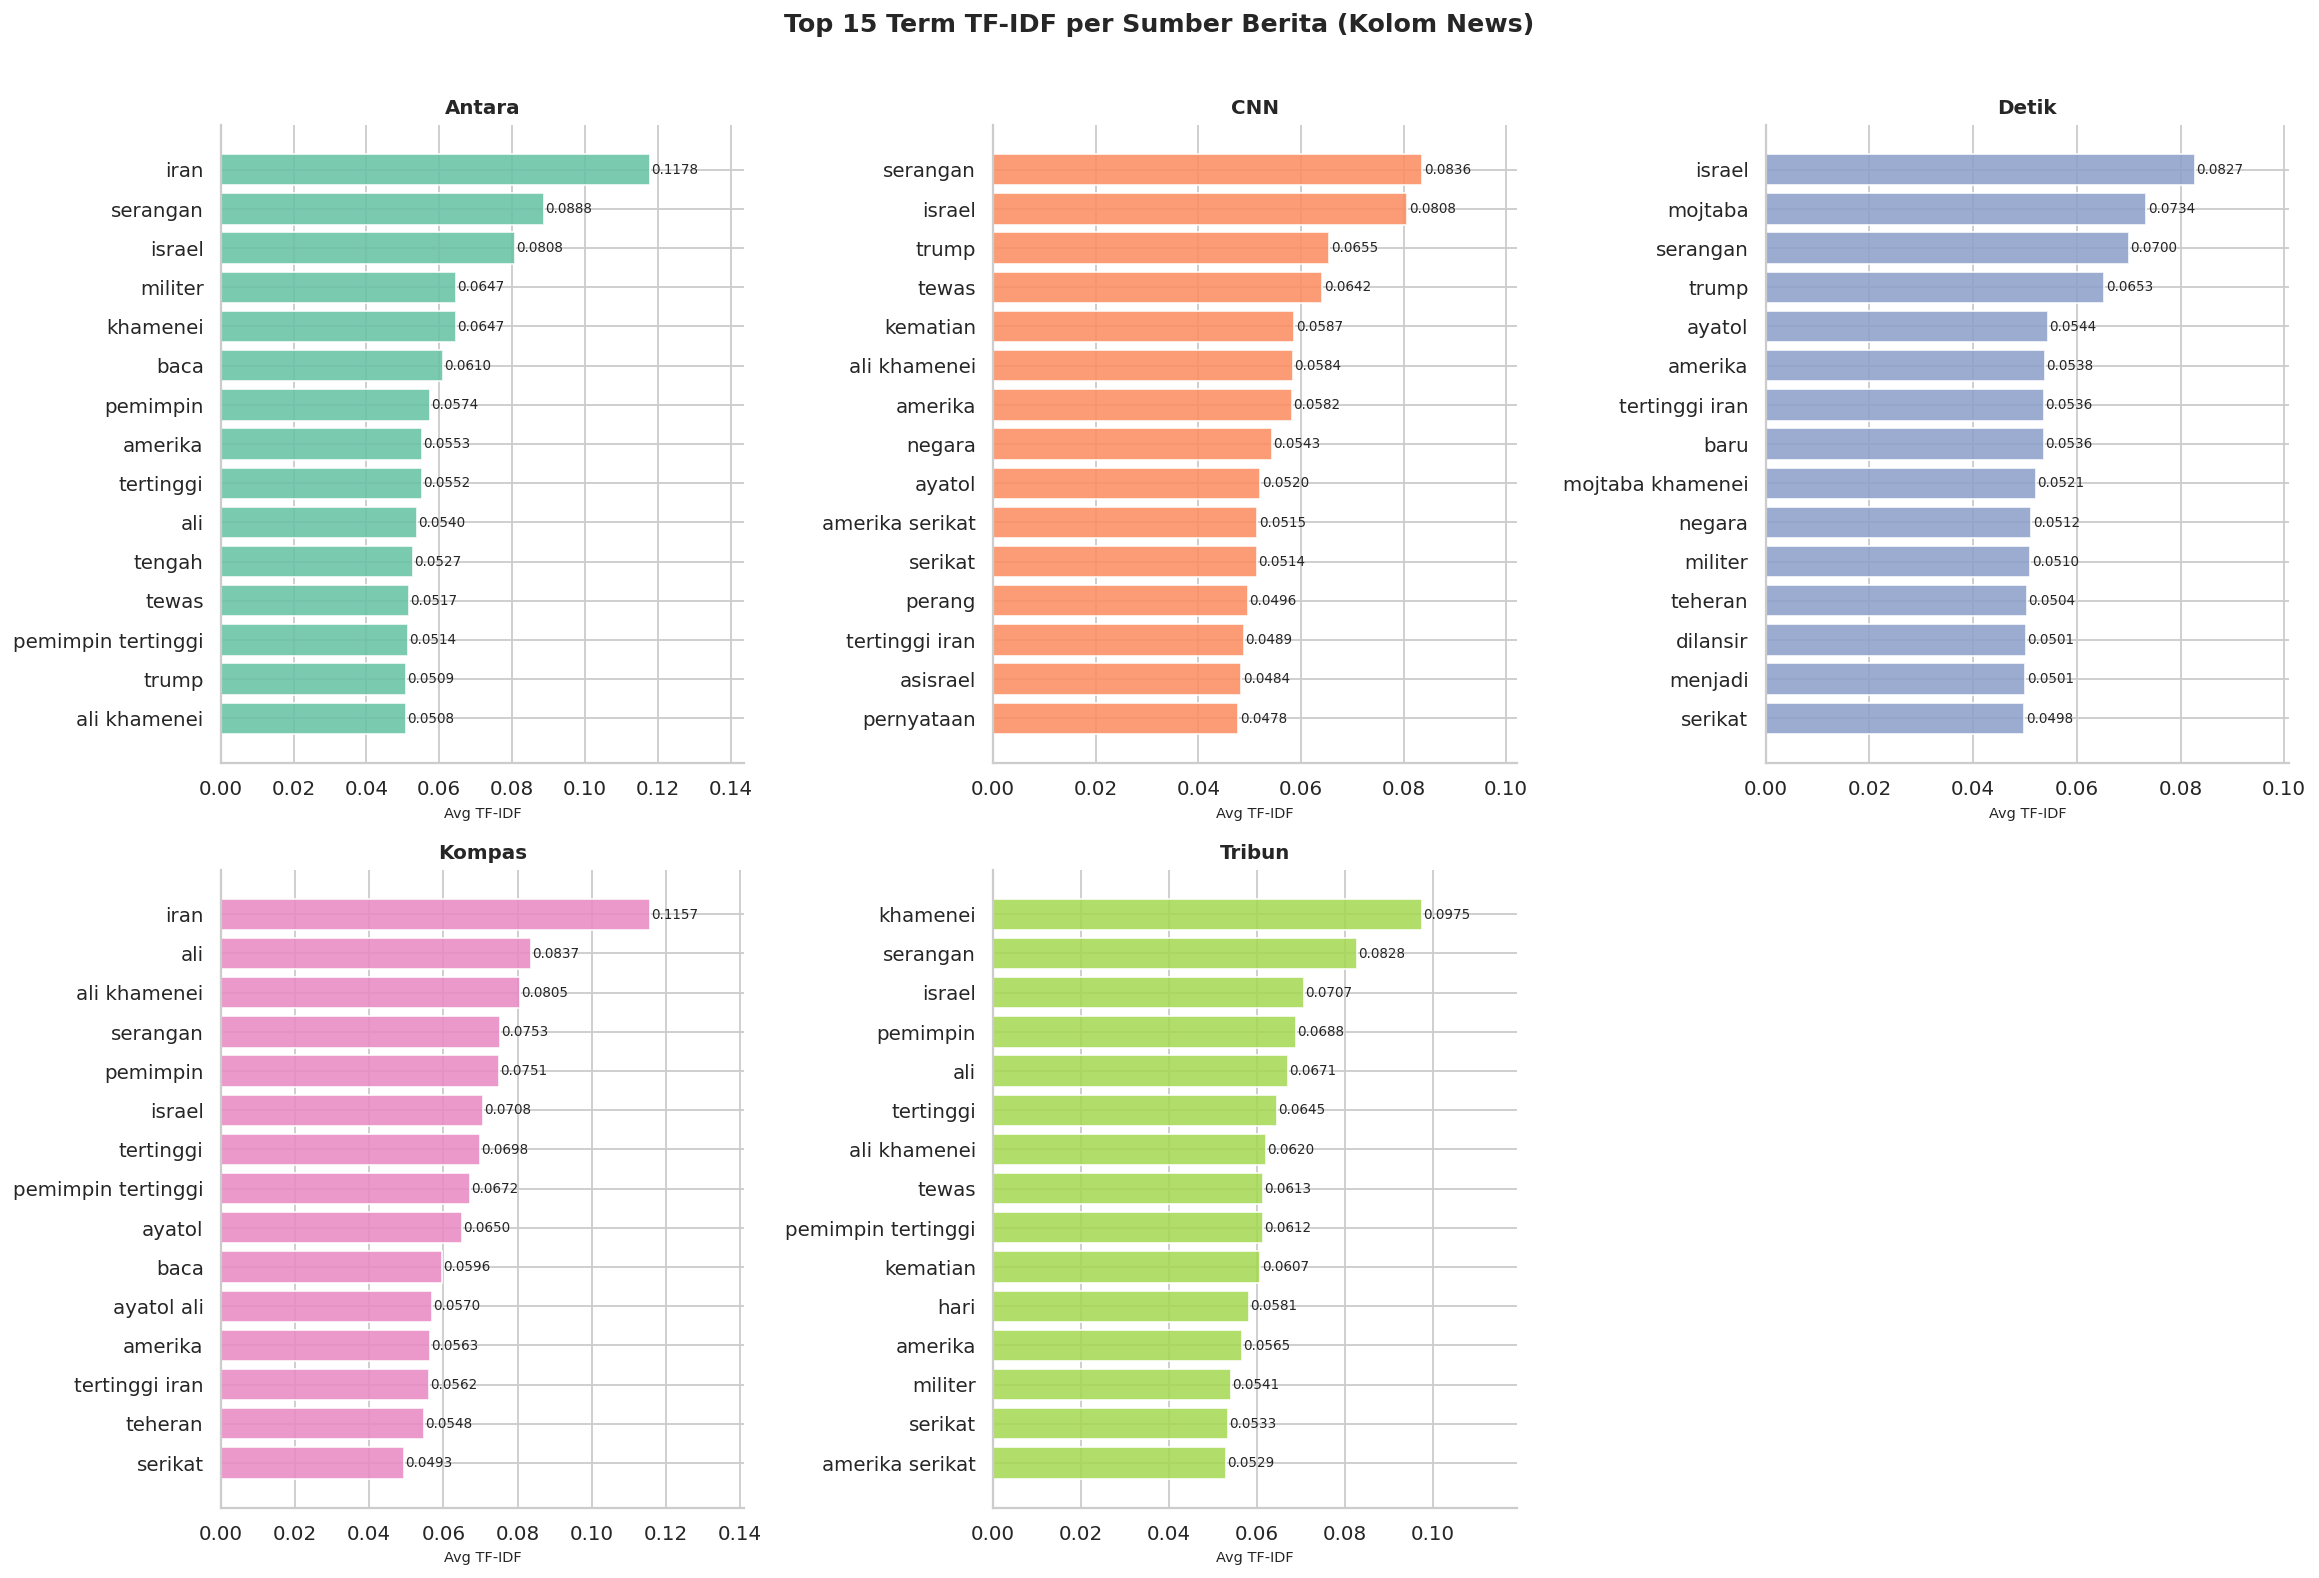

💾 viz_tfidf_per_news.png


In [16]:
if results_channel:
    plot_segment_top_words(
        results_channel,
        title=f'Top {TOP_N} Term TF-IDF per Sumber Berita (Kolom News)',
        fname='viz_tfidf_per_news.png',
        ncols=min(3, len(results_channel))
    )

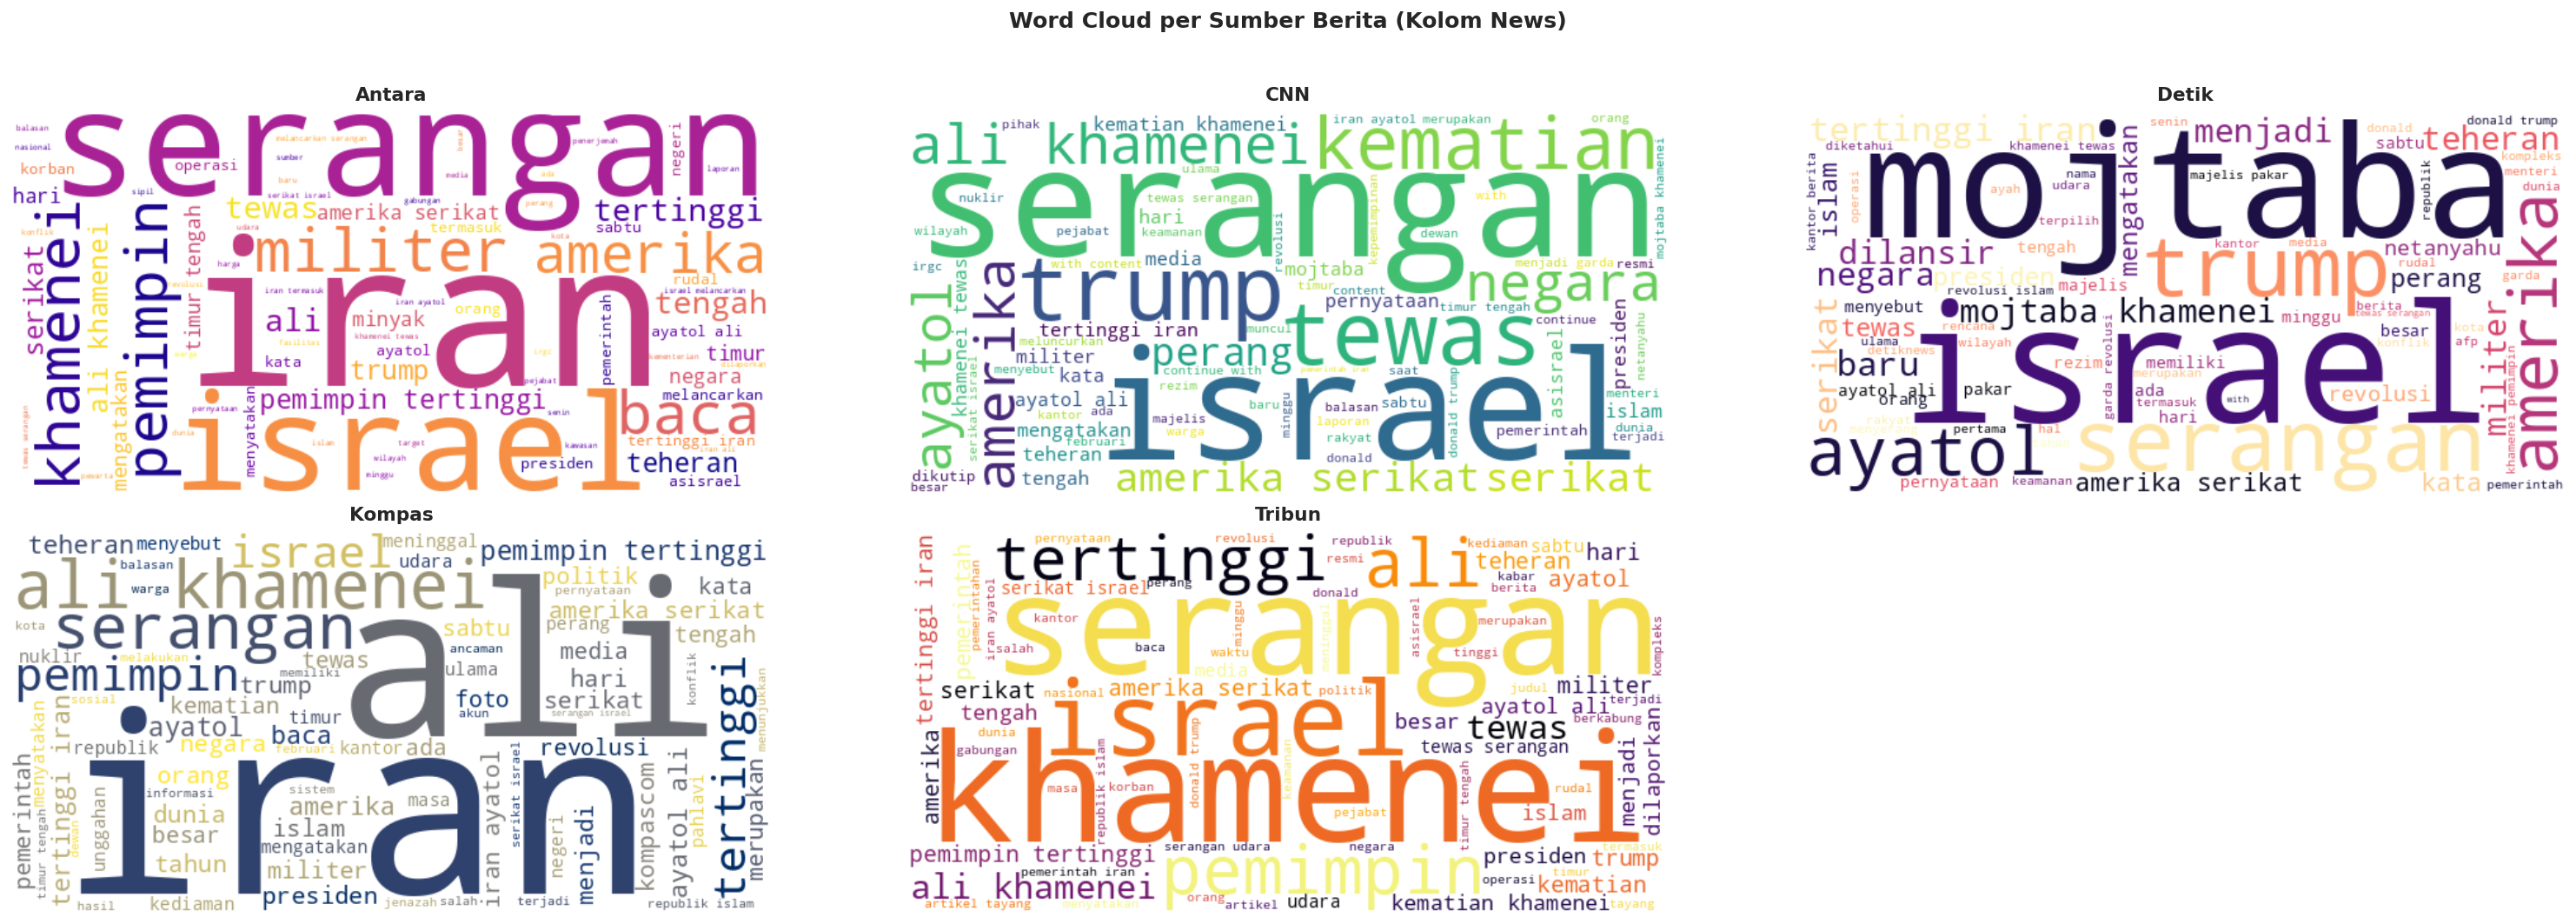

In [17]:
if results_channel:
    n = len(results_channel)
    ncols_wc = min(3, n)
    nrows_wc = (n + ncols_wc - 1) // ncols_wc

    fig, axes = plt.subplots(nrows_wc, ncols_wc,
                             figsize=(8*ncols_wc, 4*nrows_wc),
                             squeeze=False)

    cmaps_list = ['plasma','viridis','magma','cividis','inferno','cool']

    for idx, (seg, imp) in enumerate(results_channel.items()):
        ax = axes[idx//ncols_wc][idx%ncols_wc]
        try:
            wc = WordCloud(width=600, height=300,
                           background_color='white',
                           colormap=cmaps_list[idx % len(cmaps_list)],
                           max_words=80
                           ).generate_from_frequencies(imp.to_dict())
            ax.imshow(wc, interpolation='bilinear')
        except Exception:
            ax.text(0.5, 0.5, 'Data terlalu sedikit',
                    ha='center', va='center')

        ax.axis('off')
        ax.set_title(str(seg), fontsize=12, fontweight='bold', pad=8)

    # Hide subplot kosong
    for idx in range(n, nrows_wc*ncols_wc):
        axes[idx//ncols_wc][idx%ncols_wc].set_visible(False)

    fig.suptitle('Word Cloud per Sumber Berita (Kolom News)',
                 fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig('viz_wordcloud_per_news.png', bbox_inches='tight', dpi=150)
    plt.show()

# **TF-IDF per Time Frame**

## Mengapa analisis ini tidak diperlukan?

Dataset ini berfokus pada **peristiwa tunggal yang terikat waktu sangat sempit**, yaitu pemberitaan wafatnya Ali Khamenei. Karena itu, analisis TF-IDF per time frame (per bulan maupun per kuartal) **tidak memberikan nilai analitis** dan justru berpotensi menghasilkan hasil yang menyesatkan, dengan alasan berikut:

| Masalah | Penjelasan |
|---|---|
| **Distribusi data sangat tidak merata** | Hampir semua artikel terkonsentrasi di satu periode pendek (sekitar waktu kejadian). Bulan/kuartal lain hanya memiliki sedikit atau nol artikel. |
| **TF-IDF tidak stabil pada corpus kecil** | Ketika satu bulan hanya berisi 2–5 artikel, skor TF-IDF menjadi tidak representatif karena IDF dihitung dari sampel yang terlalu kecil. |
| **Tidak ada variasi narasi antar waktu** | Karena topiknya adalah satu kejadian spesifik, kosakata yang digunakan di seluruh periode hampir identik — tidak ada "term drift" yang bermakna untuk dianalisis. |
| **Risiko overfitting temporal** | Jika satu bulan kebetulan berisi artikel dengan gaya penulisan tertentu, TF-IDF akan menangkap artefak gaya itu, bukan perbedaan topik yang sesungguhnya. |
| **Informasi yang dibutuhkan sudah tercakup** | Perbedaan framing dan pilihan kata sudah lebih baik dianalisis melalui segmentasi berdasarkan **kolom News** (sumber media) dan **Sentimen**. |

> **Kesimpulan:** Untuk dataset berita tentang satu peristiwa dengan cakupan waktu terbatas, segmentasi temporal tidak menambah insight baru. Kode untuk analisis ini telah dihapus dari notebook ini.


# **(7) TF-IDF per Sentimen**

Jika dataset memiliki kolom sentimen, bagian ini mengungkap kata-kata yang khas untuk setiap kelas sentimen: **positif**, **negatif**, dan **netral**.

=== Distribusi Sentimen (kolom: "sentiment_label") ===
sentiment_label
Positive    261
Netral      176
Negative     54

✅ Berhasil: 3 kelas sentimen dianalisis


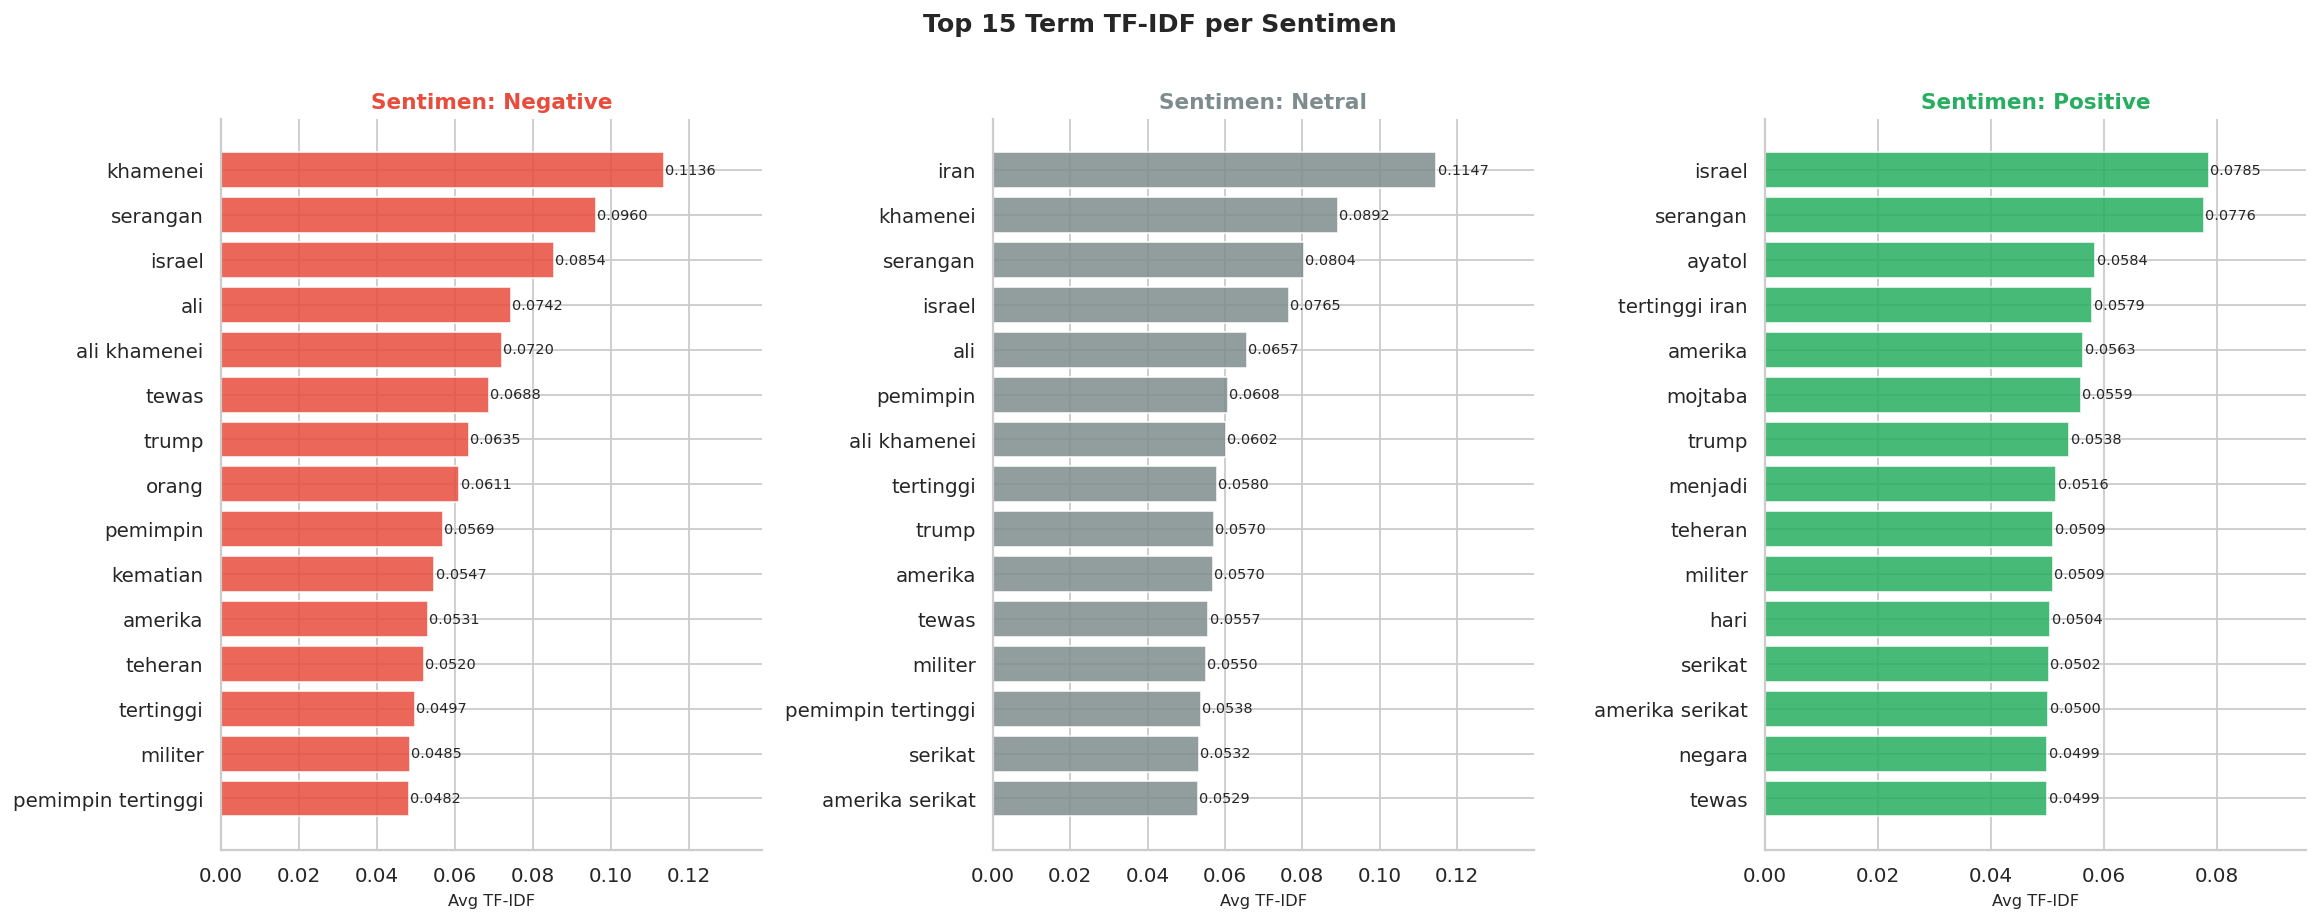

💾 viz_tfidf_per_sentimen.png


In [18]:
if COL_SENTIMENT and COL_SENTIMENT in df.columns:
    print(f'=== Distribusi Sentimen (kolom: "{COL_SENTIMENT}") ===')
    print(df[COL_SENTIMENT].value_counts().to_string())

    results_sentiment = tfidf_per_segment(
        df, COL_SENTIMENT, 'text_semantic', label_col_name='Sentimen')
    print(f'\n✅ Berhasil: {len(results_sentiment)} kelas sentimen dianalisis')

    if results_sentiment:
        SENTIMENT_COLORS = {
            'positive':'#27ae60', 'positif':'#27ae60',
            'negative':'#e74c3c', 'negatif':'#e74c3c',
            'neutral':'#7f8c8d',  'netral':'#7f8c8d',
        }
        n = len(results_sentiment)
        fig, axes = plt.subplots(1, n, figsize=(6*n, 7))
        if n == 1: axes = [axes]
        for ax, (seg, imp) in zip(axes, results_sentiment.items()):
            top = imp.head(TOP_N)
            color = SENTIMENT_COLORS.get(str(seg).lower(), '#3498db')
            bars = ax.barh(top.index[::-1], top.values[::-1],
                           color=color, alpha=0.85, edgecolor='white')
            for bar, val in zip(bars, top.values[::-1]):
                ax.text(bar.get_width()+0.0003, bar.get_y()+bar.get_height()/2,
                        f'{val:.4f}', va='center', fontsize=8)
            ax.set_title(f'Sentimen: {seg}', fontsize=12, fontweight='bold', color=color)
            ax.set_xlabel('Avg TF-IDF', fontsize=9)
            ax.set_xlim(0, top.max()*1.22)
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        fig.suptitle(f'Top {TOP_N} Term TF-IDF per Sentimen',
                     fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig('viz_tfidf_per_sentimen.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('💾 viz_tfidf_per_sentimen.png')
else:
    print('⚠️  Kolom sentimen tidak ditemukan.')
    print('   Ganti nilai COL_SENTIMENT di bagian (2) sesuai kolom di dataset Anda.')
    results_sentiment = {}

# **(8) NER Analysis — Named Entity Recognition**

Menggunakan hasil POS Tagging untuk mengekstrak **Named Entities** — yaitu kata-kata dengan tag `PROPN` (nama diri). Entitas ini mencakup: nama orang, negara, organisasi, dan tempat. Kemudian dihitung dengan TF-IDF untuk melihat entitas mana yang paling signifikan secara informatif.

In [19]:
if COL_POSTAGS:
    # Extract entitas dari PROPN
    def extract_entities(pos_list):
        """Ekstrak PROPN sebagai proxy Named Entities."""
        entities = []
        i, n = 0, len(pos_list)
        while i < n:
            word, tag = pos_list[i]
            if tag == 'PROPN':
                # Gabungkan entitas multi-kata (consecutive PROPN)
                entity_parts = [word]
                j = i + 1
                while j < n and pos_list[j][1] == 'PROPN':
                    entity_parts.append(pos_list[j][0])
                    j += 1
                entity = ' '.join(entity_parts).title()
                if len(entity) >= 3:
                    entities.append(entity)
                i = j
            else:
                i += 1
        return entities

    df['entities'] = df[COL_POSTAGS].apply(extract_entities)

    # Frekuensi global semua entitas

    all_entities = list(chain.from_iterable(df['entities']))
    entity_counter = Counter(all_entities)

    print(f'✅ Total entitas diekstrak: {len(all_entities):,}')
    print(f'   Entitas unik           : {len(entity_counter):,}')
    print(f'\n=== Top 20 Named Entities (berdasarkan frekuensi) ===')
    df_ner = pd.DataFrame(entity_counter.most_common(30),
                          columns=['Entitas', 'Frekuensi'])
    display(df_ner.head(20))

    # TF-IDF khusus entity
    df['text_entities'] = df['entities'].apply(lambda x: ' '.join(x))
    corpus_ner = df['text_entities'].fillna('').astype(str)
    valid_ner = corpus_ner[corpus_ner.str.strip() != '']

    if len(valid_ner) >= 3:
        vec_ner = TfidfVectorizer(max_features=300, ngram_range=(1,2),
                                  min_df=2, max_df=0.95, sublinear_tf=True,
                                  token_pattern=r'[A-Za-z][A-Za-z ]+')
        try:
            mat_ner = vec_ner.fit_transform(corpus_ner)
            imp_ner = pd.DataFrame(mat_ner.toarray(), columns=vec_ner.get_feature_names_out()
                                  ).mean(axis=0).sort_values(ascending=False)
            print(f'\n=== Top {TOP_N} Named Entities (berdasarkan TF-IDF) ===')
            display(imp_ner.head(TOP_N).reset_index().rename(
                columns={'index':'Entitas', 0:'Avg TF-IDF'}))
        except Exception as e:
            print(f'⚠️  TF-IDF NER gagal: {e}')
            imp_ner = pd.Series(entity_counter).sort_values(ascending=False)
    else:
        imp_ner = None
        print('⚠️  Terlalu sedikit dokumen berisi entitas.')
else:
    print('⚠️  Kolom pos_tags tidak tersedia — NER Analysis dilewati.')
    imp_ner = None

✅ Total entitas diekstrak: 4,906
   Entitas unik           : 1,017

=== Top 20 Named Entities (berdasarkan frekuensi) ===


,Entitas,Frekuensi
0,Amerika Serikat,348
1,Amerika,297
2,Trump,258
3,Khamenei,221
4,Israel,128
5,Ali Khamenei,110
6,Ali,107
7,As Donald Trump,101
8,China,94
9,Indonesia,90



=== Top 15 Named Entities (berdasarkan TF-IDF) ===


,Entitas,Avg TF-IDF
0,copyright,0.010183
1,amerika serikat,0.008147
2,khamenei,0.006110
3,appstore playstore,0.006110
4,ali khamenei amerika serikat sabtu amerika ser...,0.006110
5,ali israel amerika serikat amerika as donald t...,0.004073
6,ali larijani amerika serikat anadolu mojtaba a...,0.004073
7,ali khamenei saudi ali khamenei ilahi khomeini...,0.004073
8,ali khamenei amerika amerika serikat donald tr...,0.004073
9,ayatol amerika februari to continue with conte...,0.004073


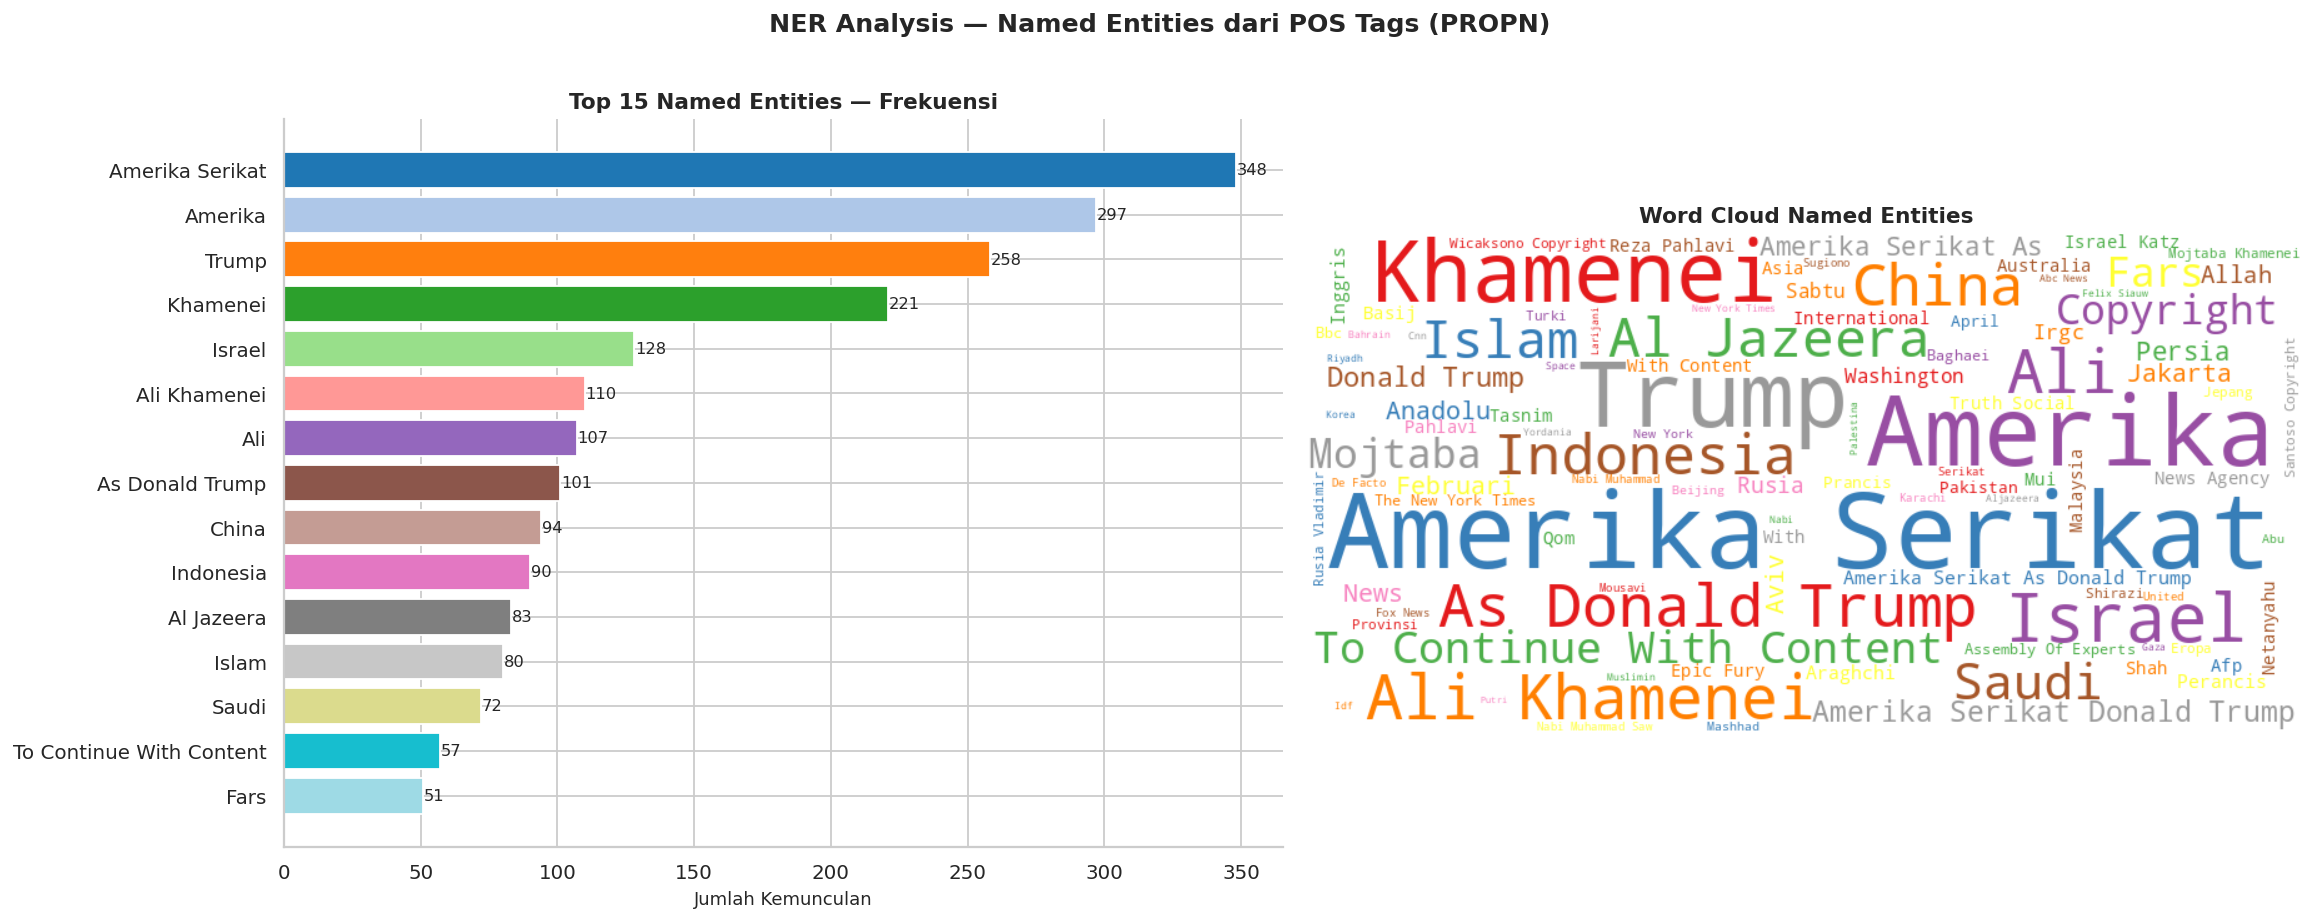

💾 viz_ner_analysis.png

=== Top 5 Entitas per Kanal ===
  [Antara]: China, Amerika Serikat, Amerika, Copyright, Indonesia
  [CNN]: Amerika Serikat, Amerika, Trump, Khamenei, Israel
  [Detik]: Trump, Amerika Serikat, Amerika, Israel, Khamenei
  [Kompas]: Amerika, Amerika Serikat, Khamenei, Trump, Saudi
  [Tribun]: Amerika Serikat, Trump, Amerika, Khamenei, Ali Khamenei


In [20]:
# ─── Visualisasi NER ─────────────────────────────────────────────────────────
if COL_POSTAGS and 'entity_counter' in dir() and entity_counter:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # (a) Bar chart: frekuensi
    ax = axes[0]
    top_ent = pd.Series(entity_counter).nlargest(TOP_N)
    colors = cm.tab20(np.linspace(0, 1, len(top_ent)))
    bars = ax.barh(top_ent.index[::-1], top_ent.values[::-1],
                   color=colors[::-1], edgecolor='white')
    for bar, val in zip(bars, top_ent.values[::-1]):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                str(int(val)), va='center', fontsize=9)
    ax.set_title(f'Top {TOP_N} Named Entities — Frekuensi',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Jumlah Kemunculan', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # (b) Word Cloud entitas
    ax = axes[1]
    wc_ner = WordCloud(width=800, height=400, background_color='white',
                       colormap='Set1', max_words=100
                       ).generate_from_frequencies(entity_counter)
    ax.imshow(wc_ner, interpolation='bilinear'); ax.axis('off')
    ax.set_title('Word Cloud Named Entities', fontsize=12, fontweight='bold')

    fig.suptitle('NER Analysis — Named Entities dari POS Tags (PROPN)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('viz_ner_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('💾 viz_ner_analysis.png')

    # ─── NER per Kanal (jika tersedia) ────────────────────────────────────────
    if COL_CHANNEL and results_channel:
        print('\n=== Top 5 Entitas per Kanal ===')
        for seg in results_channel:
            sub = df[df[COL_CHANNEL]==seg]
            ents = list(chain.from_iterable(sub['entities'].dropna()))
            top5 = Counter(ents).most_common(5)
            print(f'  [{seg}]: {", ".join([e for e,_ in top5]) if top5 else "(kosong)"}')

# **(9) Visualisasi Tambahan**

## Cosine Similarity Antar Dokumen

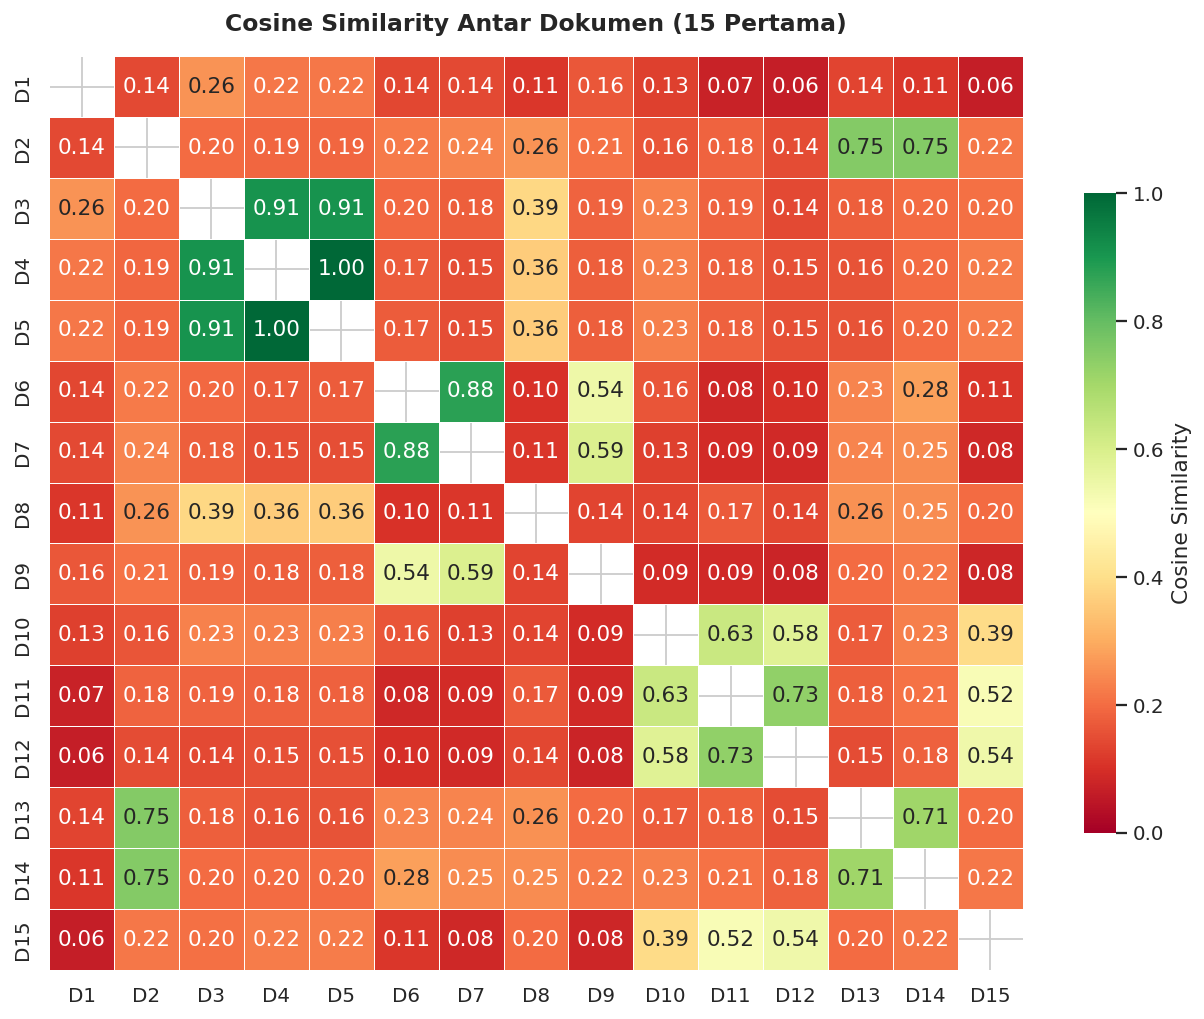

💾 viz_cosine_similarity.png
   Avg similarity antar dok : 0.2508


In [21]:
n_sample  = min(15, len(df))
cos_sim   = cosine_similarity(mat_global[:n_sample])
labels_cs = [f'D{i+1}' for i in range(n_sample)]

fig, ax = plt.subplots(figsize=(10, 8))
mask_diag = np.eye(n_sample, dtype=bool)
sns.heatmap(cos_sim, xticklabels=labels_cs, yticklabels=labels_cs,
            cmap='RdYlGn', vmin=0, vmax=1, annot=True, fmt='.2f',
            linewidths=0.4, linecolor='white', mask=mask_diag,
            cbar_kws={'label':'Cosine Similarity','shrink':0.7}, ax=ax)
ax.set_title(f'Cosine Similarity Antar Dokumen ({n_sample} Pertama)',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('viz_cosine_similarity.png', bbox_inches='tight', dpi=150)
plt.show()
np.fill_diagonal(cos_sim, 0)
print(f'💾 viz_cosine_similarity.png')
print(f'   Avg similarity antar dok : {cos_sim.sum()/(n_sample*(n_sample-1)):.4f}')

# **(11) Ringkasan Otomatis & Insight**

In [22]:
print('='*68)
print('   RINGKASAN ANALISIS TF-IDF — AUTO-GENERATED INSIGHTS')
print('='*68)
print(f'  Total dokumen : {len(df):,}')
print(f'  Total fitur   : {mat_global.shape[1]:,}')
sparsity_pct = (1 - mat_global.nnz/(mat_global.shape[0]*mat_global.shape[1]))*100
print(f'  Sparsity      : {sparsity_pct:.1f}%')
print()

# Top terms global
print('  ▸ Top 5 Term Paling Informatif (Global):')
for i, (t, s) in enumerate(importance_global.head(5).items(), 1):
    n_words = len(t.split())
    kind = {1:'unigram', 2:'bigram', 3:'trigram'}.get(n_words, f'{n_words}-gram')
    print(f'    {i}. "{t}" ({kind}) — skor: {s:.4f}')
print()

# N-gram breakdown
print('  ▸ N-Gram Breakdown:')
for n, (label, scores) in ngram_importance.items():
    top3 = scores.head(3).index.tolist()
    print(f'    {label}: {", ".join([f"{chr(34)}{t}{chr(34)}" for t in top3])}')
print()

# POS
if tfidf_pos:
    print('  ▸ Term Dominan per POS Tag:')
    for tag, (vec, mat, imp) in tfidf_pos.items():
        label, _ = POS_CONFIG[tag]
        top3 = imp.head(3).index.tolist()
        print(f'    {label} ({tag}): {", ".join(top3)}')
    print()

# News
if results_channel:
    print('  ▸ Term Khas per Sumber Berita (News):')
    for seg, imp in results_channel.items():
        print(f'    [{seg}]: {imp.head(3).index.tolist()}')
    print()

# Sentimen
if results_sentiment:
    print('  ▸ Term Khas per Sentimen:')
    for seg, imp in results_sentiment.items():
        print(f'    [{seg}]: {imp.head(3).index.tolist()}')
    print()

# NER
if COL_POSTAGS and 'entity_counter' in dir() and entity_counter:
    top_ents = [e for e,_ in Counter(entity_counter).most_common(5)]
    print(f'  ▸ Top 5 Named Entities: {", ".join(top_ents)}')
    print()


   RINGKASAN ANALISIS TF-IDF — AUTO-GENERATED INSIGHTS
  Total dokumen : 491
  Total fitur   : 800
  Sparsity      : 85.3%

  ▸ Top 5 Term Paling Informatif (Global):
    1. "serangan" (unigram) — skor: 0.0571
    2. "israel" (unigram) — skor: 0.0554
    3. "pemimpin tertinggi" (bigram) — skor: 0.0438
    4. "trump" (unigram) — skor: 0.0403
    5. "amerika" (unigram) — skor: 0.0399

  ▸ N-Gram Breakdown:
    Unigram (1 kata): "serangan", "israel", "trump"
    Bigram (2 kata): "pemimpin tertinggi", "tertinggi iran", "amerika serikat"
    Trigram (3 kata): "pemimpin tertinggi iran", "ayatol ali khamenei", "iran ayatol ali"

  ▸ Term Dominan per POS Tag:
    Kata Benda (NOUN): khamenei, serangan, israel
    Nama Diri (PROPN): amerika, serikat, trump
    Kata Kerja (VERB): tewas, menjadi, baca
    Kata Sifat (ADJ): tertinggi, militer, besar
    Keterangan (ADV): juga, lebih, kemudian

  ▸ Term Khas per Sumber Berita (News):
    [Antara]: ['iran', 'serangan', 'israel']
    [CNN]: ['serangan

# **(12) Ekspor Hasil ke CSV**

In [23]:
# (A) Artikel dengan keyword
df_export = df.copy()
for col in ['entities', 'keywords_tfidf', COL_POSTAGS]:
    if col and col in df_export.columns:
        df_export[col] = df_export[col].apply(str)
df_export.to_csv('tfidf_articles.csv', index=False)
print('✅ tfidf_articles.csv')

# (B) Ranking term global
ranking = pd.DataFrame({
    'rank': range(1, len(importance_global)+1),
    'term': importance_global.index,
    'avg_tfidf': importance_global.values,
    'doc_frequency': df_freq_arr[importance_global.index].values,
    'ngram_n': [len(t.split()) for t in importance_global.index],
})
ranking.to_csv('tfidf_term_ranking.csv', index=False)
print('✅ tfidf_term_ranking.csv')

# (C) Ranking per POS
if tfidf_pos:
    frames = []
    for tag, (vec, mat, imp) in tfidf_pos.items():
        t = imp.head(100).reset_index()
        t.columns = ['term','avg_tfidf']
        t['pos_tag'] = tag
        t['pos_label'] = POS_CONFIG[tag][0]
        frames.append(t)
    pd.concat(frames, ignore_index=True).to_csv('tfidf_per_pos_ranking.csv', index=False)
    print('✅ tfidf_per_pos_ranking.csv')

# (D) NER ranking
if COL_POSTAGS and 'entity_counter' in dir() and entity_counter:
    pd.DataFrame(entity_counter.most_common(),
                 columns=['entity','frequency']).to_csv('ner_entity_ranking.csv', index=False)
    print('✅ ner_entity_ranking.csv')

# (E) Segmen rankings
all_segment_results = []
for seg_name, results in [
    ('news', results_channel),
    ('sentimen', results_sentiment)
]:
    for seg, imp in results.items():
        top = imp.head(50).reset_index()
        top.columns = ['term','avg_tfidf']
        top['segment_type'] = seg_name
        top['segment_value'] = str(seg)
        all_segment_results.append(top)
if all_segment_results:
    pd.concat(all_segment_results, ignore_index=True).to_csv(
        'tfidf_per_segment_ranking.csv', index=False)
    print('✅ tfidf_per_segment_ranking.csv')

print()
print('🎉 Semua file berhasil diekspor!')

✅ tfidf_articles.csv
✅ tfidf_term_ranking.csv
✅ tfidf_per_pos_ranking.csv
✅ ner_entity_ranking.csv
✅ tfidf_per_segment_ranking.csv

🎉 Semua file berhasil diekspor!
